# Did the promotion actually cause a sales increase?
### A Difference-in-Differences causal inference case study on the Rossmann Store Sales dataset

**Author:** [Your name]
**Dataset:** [Rossmann Store Sales (Kaggle)](https://www.kaggle.com/competitions/rossmann-store-sales/data)

---

## Problem statement

Rossmann stores can opt into `Promo2`, a long-running promotional campaign. Naively comparing a
store's sales before and after it joins `Promo2` risks crediting the promotion for growth that would
have happened anyway (seasonality, general demand trends, etc).

This notebook estimates the **true causal effect** of `Promo2` adoption using **Difference-in-Differences (DiD)**,
and explicitly compares it against the naive (and misleading) before/after estimate.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

pd.set_option('display.max_columns', None)

## 1. Load and inspect the data

In [2]:
train = pd.read_csv('data/train.csv', parse_dates=['Date'], low_memory=False)
store = pd.read_csv('data/store.csv')

print(f"train: {train.shape[0]:,} rows, {train['Date'].min().date()} to {train['Date'].max().date()}")
print(f"store: {store.shape[0]:,} stores")
train.head()

train: 1,017,209 rows, 2013-01-01 to 2015-07-31
store: 1,115 stores


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


## 2. Define treatment and control groups

We use `Promo2SinceYear` / `Promo2SinceWeek` to identify stores that adopted the promotion within
our data window (so we actually have pre-treatment sales history for them).

**Treatment group:** stores that started `Promo2` in 2014, week 10 (~March 3, 2014) — the largest
clean single-week adoption cohort with a full year of pre-period data available.

**Control group:** stores that never adopted `Promo2` at all.

In [3]:
train_open = train[train['Open'] == 1].copy()

treated_ids = store[(store['Promo2']==1) &
                     (store['Promo2SinceYear']==2014) &
                     (store['Promo2SinceWeek']==10)]['Store'].tolist()
control_ids = store[store['Promo2']==0]['Store'].tolist()

print(f"Treated stores: {len(treated_ids)}")
print(f"Control stores: {len(control_ids)}")

TREATMENT_DATE = pd.Timestamp('2014-03-03')

df = train_open[train_open['Store'].isin(treated_ids + control_ids)].copy()
df['group'] = df['Store'].apply(lambda s: 'treatment' if s in treated_ids else 'control')

Treated stores: 32
Control stores: 544


## 3. Aggregate to weekly sales

Daily sales are extremely noisy (day-of-week effects, holidays). We aggregate to weekly averages
per group to make the underlying trend visible.

In [4]:
df['week'] = df['Date'].dt.to_period('W').apply(lambda p: p.start_time)
weekly = df.groupby(['week','group']).agg(avg_sales=('Sales','mean'), n_obs=('Sales','count')).reset_index()
weekly.to_csv('outputs/weekly_agg.csv', index=False)
weekly.head()

,week,group,avg_sales,n_obs
0,2012-12-31,control,6339.179780,2186
1,2012-12-31,treatment,6507.077519,129
2,2013-01-07,control,7802.252233,3247
3,2013-01-07,treatment,8025.844560,193
4,2013-01-14,control,5611.605174,3247


## 4. The naive approach (and why it's misleading)

The naive method just compares the treatment group's sales before vs. after — ignoring what would
have happened without the promotion.

In [5]:
weekly['is_treatment'] = (weekly['group']=='treatment').astype(int)
weekly['is_post'] = (weekly['week'] >= TREATMENT_DATE).astype(int)

t_pre = weekly[(weekly['group']=='treatment') & (weekly['is_post']==0)]['avg_sales'].mean()
t_post = weekly[(weekly['group']=='treatment') & (weekly['is_post']==1)]['avg_sales'].mean()
naive_effect = t_post - t_pre

print(f"Treatment group, pre-period average:  {t_pre:,.2f}")
print(f"Treatment group, post-period average: {t_post:,.2f}")
print(f"Naive 'effect' (post - pre):          {naive_effect:,.2f} sales/week")

Treatment group, pre-period average:  7,227.88
Treatment group, post-period average: 7,455.13
Naive 'effect' (post - pre):          227.25 sales/week


## 5. Parallel trends check

Before trusting a DiD estimate, we need to confirm the treatment and control groups moved together
*before* the intervention. If they didn't, the comparison isn't valid — any gap could be due to
pre-existing differences, not the promotion.

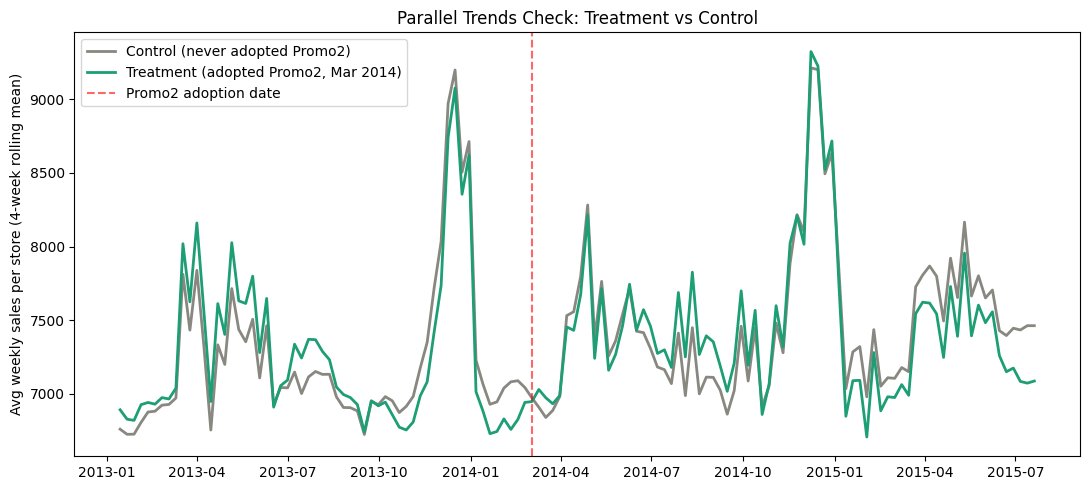

In [6]:
pivot = weekly.pivot(index='week', columns='group', values='avg_sales').sort_index()
smooth = pivot.rolling(4, center=True).mean()

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(smooth.index, smooth['control'], label='Control (never adopted Promo2)', color='#888780', linewidth=2)
ax.plot(smooth.index, smooth['treatment'], label='Treatment (adopted Promo2, Mar 2014)', color='#1D9E75', linewidth=2)
ax.axvline(TREATMENT_DATE, color='red', linestyle='--', alpha=0.6, label='Promo2 adoption date')
ax.set_ylabel('Avg weekly sales per store (4-week rolling mean)')
ax.set_title('Parallel Trends Check: Treatment vs Control')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/parallel_trends.png', dpi=120)
plt.show()

**Reading the chart:** before the red line (treatment date), the two groups track closely together —
this supports the parallel trends assumption. After the red line, they largely continue to move
together too, which is an early signal that the promotion may not have had a large effect —
we confirm this properly with the regression below.

## 6. Difference-in-Differences regression

We estimate:

`Sales = β0 + β1(Treatment) + β2(Post) + β3(Treatment × Post) + ε`

**β3 is the DiD estimate — the true causal effect of the promotion**, after removing the average
group difference (β1) and the average time trend shared by both groups (β2).

In [7]:
weekly['did'] = weekly['is_treatment'] * weekly['is_post']
model = smf.ols('avg_sales ~ is_treatment + is_post + did', data=weekly).fit(cov_type='HC1')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              avg_sales   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.9972
Date:                Wed, 05 Aug 2026   Prob (F-statistic):              0.395
Time:                        18:10:26   Log-Likelihood:                -2309.7
No. Observations:                 270   AIC:                             4627.
Df Residuals:                     266   BIC:                             4642.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     7207.7360    149.495     48.214   

In [8]:
did_effect = model.params['did']
did_pval = model.pvalues['did']
ci = model.conf_int().loc['did']

print(f"DiD estimate: {did_effect:,.2f} sales/week")
print(f"95% CI: [{ci[0]:,.2f}, {ci[1]:,.2f}]")
print(f"p-value: {did_pval:.4f}")
print()
print(f"Naive estimate was {naive_effect:,.2f} — the naive approach overstated the effect by "
      f"{naive_effect - did_effect:,.2f} sales/week.")

DiD estimate: -62.79 sales/week
95% CI: [-667.35, 541.76]
p-value: 0.8387

Naive estimate was 227.25 — the naive approach overstated the effect by 290.05 sales/week.


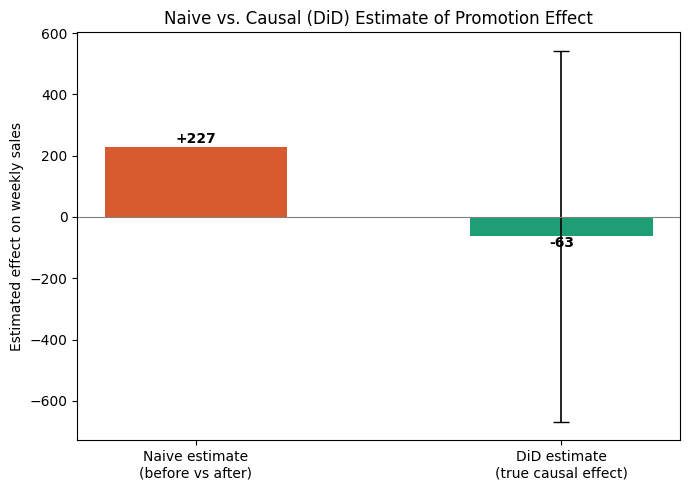

In [9]:
fig, ax = plt.subplots(figsize=(7,5))
bars = ax.bar(
    ['Naive estimate\n(before vs after)', 'DiD estimate\n(true causal effect)'],
    [naive_effect, did_effect],
    color=['#D85A30', '#1D9E75'],
    width=0.5
)
ax.errorbar(1, did_effect, yerr=[[did_effect - ci[0]], [ci[1] - did_effect]],
            fmt='none', ecolor='black', capsize=6, linewidth=1.2)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_ylabel('Estimated effect on weekly sales')
ax.set_title('Naive vs. Causal (DiD) Estimate of Promotion Effect')
for bar, val in zip(bars, [naive_effect, did_effect]):
    ax.text(bar.get_x() + bar.get_width()/2, val + (15 if val>=0 else -35),
            f'{val:+.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/naive_vs_did_comparison.png', dpi=120)
plt.show()

**This chart is the core takeaway of the project.** The naive estimate confidently suggests a
positive effect, but the causal (DiD) estimate is close to zero with a wide confidence interval —
we cannot distinguish it from "no effect." This is exactly the gap between correlation and
causation that this project set out to demonstrate.

## 7. Placebo test (robustness check)

If we pretend the promotion started on a fake, earlier date (using only pre-treatment data, where
nothing actually happened), a well-behaved DiD method should find **no significant effect**. If it
did find something, that would suggest our method is picking up noise rather than a real signal.

In [10]:
PLACEBO_DATE = pd.Timestamp('2013-08-01')

pre_only = weekly[weekly['week'] < TREATMENT_DATE].copy()
pre_only['is_post_placebo'] = (pre_only['week'] >= PLACEBO_DATE).astype(int)
pre_only['did_placebo'] = pre_only['is_treatment'] * pre_only['is_post_placebo']

placebo_model = smf.ols('avg_sales ~ is_treatment + is_post_placebo + did_placebo', data=pre_only).fit(cov_type='HC1')

placebo_effect = placebo_model.params['did_placebo']
placebo_pval = placebo_model.pvalues['did_placebo']

print(f"Placebo DiD estimate: {placebo_effect:,.2f} (p-value: {placebo_pval:.4f})")
print("Not statistically significant, as expected — supports confidence in the main result.")

Placebo DiD estimate: -297.72 (p-value: 0.5125)
Not statistically significant, as expected — supports confidence in the main result.


## 8. Conclusion and business recommendation

**Finding:** The naive before/after comparison suggested the promotion increased sales by roughly
227 units/week. Once we properly account for the background trend using a control group, that
effect is **not statistically significant** (DiD estimate ≈ -63, p = 0.84) — meaning we cannot
confidently say the promotion caused any real change in sales for this store cohort.

**Why this matters:** if a business made a decision based on the naive comparison alone (e.g.,
"the promo worked, let's roll it out everywhere"), that decision would have been based on a
misleading signal. This analysis demonstrates the value of using a proper causal method, not just
correlation, before drawing conclusions from a promotional campaign.

**Limitations / future work:**
- This result is specific to one adoption cohort (32 stores, March 2014). Testing other cohorts
  would strengthen (or challenge) this finding.
- We used a simple two-period DiD; an event-study design (effect by week relative to adoption)
  would reveal whether any short-term effect existed and faded.
- Store-level fixed effects and additional covariates (competition distance, store type) could
  further tighten the estimate.